# DermaVision - Phase 5: TensorFlow Lite Optimization

## What is TensorFlow Lite?

TensorFlow Lite (TFLite) is designed for mobile and edge devices.

## What is Quantization?

Quantization reduces model size by converting 32-bit floats to 8-bit integers.
- Model becomes 4x smaller
- Inference becomes faster
- Some accuracy may be lost

---

In [1]:
import tensorflow as tf
import numpy as np
import os
import shutil

BACKUP_DIR = 'backup/DermaVision'

# Load data
if os.path.exists('X_test.npy'):
    print("Loading from local...")
elif os.path.exists(os.path.join(BACKUP_DIR, 'X_test.npy')):
    print(f"Loading from backup ({BACKUP_DIR})...")
    for file in ['X_test.npy', 'y_test.npy', 'label_classes.npy']:
        shutil.copy(os.path.join(BACKUP_DIR, file), '.')
    # Also try to copy models if they exist in backup
    for model_file in ['fl_noniid_model.keras', 'fl_iid_model.keras', 'baseline_model.keras']:
        if os.path.exists(os.path.join(BACKUP_DIR, model_file)) and not os.path.exists(model_file):
            shutil.copy(os.path.join(BACKUP_DIR, model_file), '.')
else:
    print("ERROR: Data not found! Please run previous notebooks first.")

if os.path.exists('X_test.npy'):
    X_test = np.load('X_test.npy')
    y_test = np.load('y_test.npy')
    label_classes = np.load('label_classes.npy')

# Load best model (IID usually better)
if os.path.exists('fl_noniid_model.keras'):
    model = tf.keras.models.load_model('fl_noniid_model.keras')
    model_name = 'FL Non-IID'
elif os.path.exists('fl_iid_model.keras'):
    model = tf.keras.models.load_model('fl_iid_model.keras')
    model_name = 'FL IID'
elif os.path.exists('baseline_model.keras'):
    model = tf.keras.models.load_model('baseline_model.keras')
    model_name = 'Baseline'
else:
    print("WARNING: No model found! Please train a model first.")
    model = None

if model:
    original_size = os.path.getsize(f'{model_name.lower().replace(" ", "_")}_model.keras' if 'FL' not in model_name else 'fl_iid_model.keras') / (1024*1024)
    print(f"Loaded {model_name} model ({original_size:.2f} MB)")

Loading from local...
Loaded FL Non-IID model (10.43 MB)


d:\Anaconda\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 114 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [2]:
# Evaluate original
if 'model' in locals() and model:
    original_loss, original_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Original Accuracy: {original_accuracy*100:.2f}%")

Original Accuracy: 79.00%


In [3]:
# Convert to TFLite with quantization
if 'model' in locals() and model:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    print("Converting to TFLite...")
    tflite_model = converter.convert()

    tflite_path = 'dermavision_optimized.tflite'
    with open(tflite_path, 'wb') as f:
        f.write(tflite_model)

    tflite_size = os.path.getsize(tflite_path) / (1024*1024)
    print(f"Done: TFLite model saved ({tflite_size:.2f} MB)")

Converting to TFLite...
INFO:tensorflow:Assets written to: C:\Users\asus\AppData\Local\Temp\tmpdrv4r8w8\assets


INFO:tensorflow:Assets written to: C:\Users\asus\AppData\Local\Temp\tmpdrv4r8w8\assets


Saved artifact at 'C:\Users\asus\AppData\Local\Temp\tmpdrv4r8w8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  1906830551248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1906830551056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1906830551824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1906830552592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1906830552016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1906830552400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1906830552208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1906830553168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1906830550480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1906830552976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1906830

SIZE COMPARISON
Original: 10.43 MB
TFLite:   2.72 MB
Reduction: 74.0% (3.8x smaller)


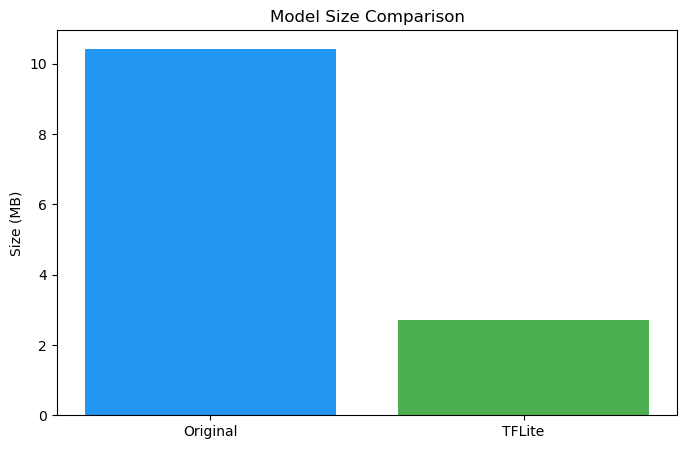

In [4]:
import matplotlib.pyplot as plt

if 'tflite_size' in locals():
    size_reduction = ((original_size - tflite_size) / original_size) * 100
    compression = original_size / tflite_size

    print("SIZE COMPARISON")
    print("=" * 40)
    print(f"Original: {original_size:.2f} MB")
    print(f"TFLite:   {tflite_size:.2f} MB")
    print(f"Reduction: {size_reduction:.1f}% ({compression:.1f}x smaller)")

    plt.figure(figsize=(8, 5))
    plt.bar(['Original', 'TFLite'], [original_size, tflite_size], color=['#2196F3', '#4CAF50'])
    plt.title('Model Size Comparison')
    plt.ylabel('Size (MB)')
    plt.savefig('model_size_comparison.png', dpi=100)
    plt.show()

In [5]:
# Test TFLite model
if 'tflite_path' in locals() and os.path.exists(tflite_path):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    def tflite_predict(image):
        if len(image.shape) == 3:
            image = np.expand_dims(image, axis=0)
        image = image.astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], image)
        interpreter.invoke()
        return interpreter.get_tensor(output_details[0]['index'])[0]

    # Evaluate
    correct = 0
    for i in range(len(X_test)):
        pred = tflite_predict(X_test[i])
        if np.argmax(pred) == np.argmax(y_test[i]):
            correct += 1

    tflite_accuracy = correct / len(X_test)
    print(f"TFLite Accuracy: {tflite_accuracy*100:.2f}%")
    print(f"Accuracy Drop: {(original_accuracy - tflite_accuracy)*100:.2f}%")

d:\Anaconda\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


TFLite Accuracy: 78.33%
Accuracy Drop: 0.67%


In [6]:
# Save results
if 'tflite_path' in locals():
    with open('tflite_results.txt', 'w') as f:
        f.write("TFLITE OPTIMIZATION RESULTS\n")
        f.write(f"Original Size: {original_size:.2f} MB\n")
        f.write(f"TFLite Size: {tflite_size:.2f} MB\n")
        f.write(f"Compression: {compression:.1f}x\n")
        f.write(f"Original Accuracy: {original_accuracy*100:.2f}%\n")
        f.write(f"TFLite Accuracy: {tflite_accuracy*100:.2f}%\n")

    # Backup
    os.makedirs(BACKUP_DIR, exist_ok=True)
    
    shutil.copy('dermavision_optimized.tflite', BACKUP_DIR)
    shutil.copy('model_size_comparison.png', BACKUP_DIR)
    shutil.copy('tflite_results.txt', BACKUP_DIR)

    print(f"Done: Backed up to {BACKUP_DIR}!")

Done: Backed up to backup/DermaVision!


---

## Phase 5 Complete

**Summary**: Model optimized for mobile deployment with minimal accuracy loss.

**Next**: Run `06_EdgeDeployment.ipynb` to test the final model.